<a href="https://colab.research.google.com/github/anshubansal371/Multimodal-AI-Interview-Analyzer/blob/main/text_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!jupyter nbconvert --ClearMetadataPreprocessor.enabled=True --inplace your_notebook.ipynb

[NbConvertApp] WARNING | pattern 'your_notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Install transformers
!pip install transformers datasets --quiet
!pip install torch --quiet

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

DATA        = '/content/drive/MyDrive/Data'
MODEL_SAVE  = '/content/drive/MyDrive/Models'
ARRAYS_PATH = '/content/drive/MyDrive/Arrays'
TEXT_ARRAYS = f'{ARRAYS_PATH}/text'
os.makedirs(MODEL_SAVE,  exist_ok=True)
os.makedirs(TEXT_ARRAYS, exist_ok=True)

print(f"✅ TF          : {tf.__version__}")
print(f"✅ GPU         : {tf.config.list_physical_devices('GPU')}")

Mounted at /content/drive
✅ TF          : 2.20.0
✅ GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Load GoEmotions ───────────────────────────────────
GO_PATH = f'{DATA}/go_emotions'
print(f"Contents : {os.listdir(GO_PATH)}")

# Load the CSV
go_csv = os.path.join(
    GO_PATH, 'go_emotions_dataset.csv')
df_go  = pd.read_csv(go_csv)

print(f"✅ GoEmotions : {len(df_go):,} rows")
print(f"   Columns    : {df_go.columns.tolist()}")
print(df_go.head(3))

# Emotion columns (28 emotions)
EMOTION_COLS = [
    'admiration','amusement','anger',
    'annoyance','approval','caring',
    'confusion','curiosity','desire',
    'disappointment','disapproval',
    'disgust','embarrassment','excitement',
    'fear','gratitude','grief','joy',
    'love','nervousness','optimism',
    'pride','realization','relief',
    'remorse','sadness','surprise','neutral']

print(f"\n✅ Emotion columns : {len(EMOTION_COLS)}")
print(f"   Sample text    : {df_go['text'].iloc[0]}")

Contents : ['go_emotions_dataset.csv']
✅ GoEmotions : 211,225 rows
   Columns    : ['id', 'text', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
        id                                               text  \
0  eew5j0j                                    That game hurt.   
1  eemcysk   >sexuality shouldn’t be a grouping category I...   
2  ed2mah1     You do right, if you don't care then fuck 'em!   

   example_very_unclear  admiration  amusement  anger  annoyance  approval  \
0                 False           0          0      0          0         0   
1                  True           0          0      0          0         0   
2                 False           0          0    

In [ ]:
# ── Map 28 GoEmotions → 7 interview emotions ──────────
# We map to emotions relevant for interview analysis

INTERVIEW_EMOTIONS = {
    0: 'angry',
    1: 'disgust',
    2: 'fearful',
    3: 'happy',
    4: 'neutral',
    5: 'sad',
    6: 'surprised'
}

# Mapping GoEmotions → interview emotions
GO_TO_INTERVIEW = {
    'anger':         0,  # angry
    'annoyance':     0,  # angry
    'disapproval':   0,  # angry
    'disgust':       1,  # disgust
    'fear':          2,  # fearful
    'nervousness':   2,  # fearful
    'amusement':     3,  # happy
    'approval':      3,  # happy
    'excitement':    3,  # happy
    'joy':           3,  # happy
    'gratitude':     3,  # happy
    'admiration':    3,  # happy
    'love':          3,  # happy
    'optimism':      3,  # happy
    'pride':         3,  # happy
    'neutral':       4,  # neutral
    'realization':   4,  # neutral
    'confusion':     4,  # neutral
    'grief':         5,  # sad
    'sadness':       5,  # sad
    'disappointment':5,  # sad
    'remorse':       5,  # sad
    'caring':        5,  # sad
    'surprise':      6,  # surprised
    'curiosity':     6,  # surprised
    'desire':        6,  # surprised
    'embarrassment': 6,  # surprised
    'relief':        4,  # neutral
}

# Get dominant emotion per row
def get_dominant_emotion(row):
    scores = {}
    for col in EMOTION_COLS:
        if col in GO_TO_INTERVIEW and \
           row[col] == 1:
            interview_em = GO_TO_INTERVIEW[col]
            scores[interview_em] = \
                scores.get(interview_em, 0) + 1
    if scores:
        return max(scores, key=scores.get)
    return 4  # default neutral

# Filter unclear examples
df_clean = df_go[
    ~df_go['example_very_unclear']].copy()

print(f"After removing unclear : {len(df_clean):,}")

# Apply mapping
print("Mapping emotions...")
df_clean['label'] = df_clean[EMOTION_COLS].apply(
    get_dominant_emotion, axis=1)

# Show distribution
print(f"\n✅ Label distribution:")
for i, name in INTERVIEW_EMOTIONS.items():
    count = (df_clean['label'] == i).sum()
    print(f"  {i} {name:10s} : {count:,}")

After removing unclear : 207,814
Mapping emotions...

✅ Label distribution:
  0 angry      : 28,683
  1 disgust    : 3,406
  2 fearful    : 3,506
  3 happy      : 70,534
  4 neutral    : 67,815
  5 sad        : 18,021
  6 surprised  : 15,849


In [ ]:
# ── Prepare text + labels ─────────────────────────────
texts  = df_clean['text'].tolist()
labels = df_clean['label'].tolist()

print(f"✅ Total samples : {len(texts):,}")
print(f"✅ Sample text   : {texts[0]}")
print(f"✅ Sample label  : "
      f"{labels[0]} → "
      f"{INTERVIEW_EMOTIONS[labels[0]]}")

# Use subset for faster training
# 50K samples is enough for good accuracy
MAX_SAMPLES = 50000
if len(texts) > MAX_SAMPLES:
    # Stratified sampling
    from sklearn.model_selection import train_test_split
    texts_sub, _, labels_sub, _ = \
        train_test_split(
            texts, labels,
            train_size=MAX_SAMPLES,
            random_state=42,
            stratify=labels)
    texts  = texts_sub
    labels = labels_sub
    print(f"✅ Using {MAX_SAMPLES:,} samples")

print(f"✅ Final samples : {len(texts):,}")

✅ Total samples : 207,814
✅ Sample text   : That game hurt.
✅ Sample label  : 5 → sad
✅ Using 50,000 samples
✅ Final samples : 50,000


In [ ]:
# ── Tokenize with DistilBERT ──────────────────────────
from transformers import DistilBertTokenizerFast

print("Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased')

MAX_LEN = 128

print(f"Tokenizing {len(texts):,} texts...")
encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='np')

input_ids      = encodings['input_ids']
attention_mask = encodings['attention_mask']

print(f"✅ input_ids shape      : {input_ids.shape}")
print(f"✅ attention_mask shape : {attention_mask.shape}")

# Save tokenized data
np.save(f'{TEXT_ARRAYS}/input_ids.npy',
        input_ids)
np.save(f'{TEXT_ARRAYS}/attention_mask.npy',
        attention_mask)
np.save(f'{TEXT_ARRAYS}/text_labels.npy',
        np.array(labels))

print("✅ Tokenized data saved!")

Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing 50,000 texts...
✅ input_ids shape      : (50000, 128)
✅ attention_mask shape : (50000, 128)
✅ Tokenized data saved!


In [ ]:
# ── Train/test split ──────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

labels_arr = np.array(labels)
NUM_CLASSES = len(INTERVIEW_EMOTIONS)

(ids_tr, ids_te,
 mask_tr, mask_te,
 y_tr, y_te) = train_test_split(
    input_ids, attention_mask, labels_arr,
    test_size=0.2,
    random_state=42,
    stratify=labels_arr)

y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
y_te_cat = to_categorical(y_te, NUM_CLASSES)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr)
class_weight_dict = dict(enumerate(class_weights))

print(f"✅ Train : {ids_tr.shape}")
print(f"✅ Test  : {ids_te.shape}")
print(f"\nClass weights:")
for i, w in class_weight_dict.items():
    print(f"  {INTERVIEW_EMOTIONS[i]:10s}: {w:.3f}")

✅ Train : (40000, 128)
✅ Test  : (10000, 128)

Class weights:
  angry     : 1.035
  disgust   : 8.711
  fearful   : 8.466
  happy     : 0.421
  neutral   : 0.438
  sad       : 1.647
  surprised : 1.874


 TF (TensorFlow) version of DistilBERT (TFDistilBertModel) was removed from the HuggingFace transformers library in newer versions (4.x+) — it now only supports PyTorch for DistilBERT, so we must use PyTorch for this model.

In [ ]:
# ── Install correct version ────────────────────────────
!pip install transformers[torch] --quiet
!pip install torch --quiet

In [ ]:
# ── Build model using HuggingFace pipeline ─────────────
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer, TrainingArguments)
import torch
from torch.utils.data import Dataset

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ GPU available   : {torch.cuda.is_available()}")
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')
print(f"✅ Device          : {device}")

✅ PyTorch version : 2.10.0+cu128
✅ GPU available   : True
✅ Device          : cuda


In [ ]:
# ── PyTorch Dataset ───────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, input_ids,
                 attention_mask, labels):
        self.input_ids      = torch.tensor(
            input_ids,      dtype=torch.long)
        self.attention_mask = torch.tensor(
            attention_mask, dtype=torch.long)
        self.labels         = torch.tensor(
            labels,         dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':
                self.input_ids[idx],
            'attention_mask':
                self.attention_mask[idx],
            'labels':
                self.labels[idx]
        }

train_dataset = EmotionDataset(
    ids_tr, mask_tr, y_tr)
test_dataset  = EmotionDataset(
    ids_te, mask_te, y_te)

print(f"✅ Train dataset : {len(train_dataset):,}")
print(f"✅ Test dataset  : {len(test_dataset):,}")

✅ Train dataset : 40,000
✅ Test dataset  : 10,000


In [ ]:
# ── Load DistilBERT for classification ────────────────
from transformers import DistilBertForSequenceClassification

text_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES)

text_model = text_model.to(device)
print(f"✅ DistilBERT loaded")
print(f"   Params  : {sum(p.numel() for p in text_model.parameters()):,}")
print(f"   Classes : {NUM_CLASSES}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT loaded
   Params  : 66,958,855
   Classes : 7


In [ ]:
# ── Training with HuggingFace Trainer ─────────────────
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(
        labels, preds)}

training_args = TrainingArguments(
    output_dir='/content/text_model_output',
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='/content/logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=torch.cuda.is_available(),
    report_to='none')

trainer = Trainer(
    model=text_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics)

print("🚀 Training DistilBERT")
print(f"   Epochs  : 5")
print(f"   Batch   : 32")
print(f"   Classes : {NUM_CLASSES}")
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Training DistilBERT
   Epochs  : 5
   Batch   : 32
   Classes : 7


Epoch,Training Loss,Validation Loss,Accuracy
1,1.146183,1.141521,0.571500
2,1.034184,1.132504,0.570700
3,0.875329,1.223761,0.555600
4,0.697159,1.407414,0.541900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

The accuracy is keep decreasing it means the model is not learning the patterns properly.

In [ ]:
# ── Stop DistilBERT — use TF-IDF + SVM instead ────────
# Much faster, less overfitting, better accuracy
# on noisy multi-class text data

!pip install scikit-learn --quiet

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score,
    classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os

MODEL_SAVE  = '/content/drive/MyDrive/Models'
TEXT_ARRAYS = '/content/drive/MyDrive/Arrays/text'
os.makedirs(f'{MODEL_SAVE}/text_model_final',
            exist_ok=True)

INTERVIEW_EMOTIONS = {
    0:'angry',   1:'disgust',
    2:'fearful', 3:'happy',
    4:'neutral', 5:'sad',
    6:'surprised'}

print("✅ Libraries ready")

✅ Libraries ready


In [ ]:
# ── Reload GoEmotions + remap ─────────────────────────
import os
from google.colab import drive

DATA    = '/content/drive/MyDrive/Data'
GO_PATH = f'{DATA}/go_emotions'

df_go = pd.read_csv(
    f'{GO_PATH}/go_emotions_dataset.csv')

EMOTION_COLS = [
    'admiration','amusement','anger',
    'annoyance','approval','caring',
    'confusion','curiosity','desire',
    'disappointment','disapproval',
    'disgust','embarrassment','excitement',
    'fear','gratitude','grief','joy',
    'love','nervousness','optimism',
    'pride','realization','relief',
    'remorse','sadness','surprise','neutral']

GO_TO_INTERVIEW = {
    'anger':0,'annoyance':0,'disapproval':0,
    'disgust':1,
    'fear':2,'nervousness':2,
    'amusement':3,'approval':3,'excitement':3,
    'joy':3,'gratitude':3,'admiration':3,
    'love':3,'optimism':3,'pride':3,
    'neutral':4,'realization':4,'confusion':4,
    'relief':4,
    'grief':5,'sadness':5,'disappointment':5,
    'remorse':5,'caring':5,
    'surprise':6,'curiosity':6,
    'desire':6,'embarrassment':6}

def get_label(row):
    scores = {}
    for col in EMOTION_COLS:
        if col in GO_TO_INTERVIEW and row[col]==1:
            em = GO_TO_INTERVIEW[col]
            scores[em] = scores.get(em,0)+1
    return max(scores,key=scores.get) \
        if scores else 4

df_clean = df_go[
    ~df_go['example_very_unclear']].copy()
df_clean['label'] = df_clean[
    EMOTION_COLS].apply(get_label, axis=1)

texts  = df_clean['text'].tolist()
labels = df_clean['label'].tolist()

print(f"✅ Total : {len(texts):,} samples")

✅ Total : 207,814 samples


In [ ]:
# ── TF-IDF Vectorization ───────────────────────────────
print("Fitting TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,3),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word')

X = vectorizer.fit_transform(texts)
y = np.array(labels)

print(f"✅ TF-IDF matrix : {X.shape}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"✅ Train : {X_tr.shape}")
print(f"✅ Test  : {X_te.shape}")

Fitting TF-IDF vectorizer...
✅ TF-IDF matrix : (207814, 50000)
✅ Train : (166251, 50000)
✅ Test  : (41563, 50000)


In [ ]:
# ── Train 3 models + pick best ────────────────────────
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr)
cw = dict(enumerate(class_weights_arr))

results = {}

# Model 1 — LinearSVC (fastest, usually best)
print("Training LinearSVC...")
svc = LinearSVC(
    class_weight='balanced',
    max_iter=2000,
    C=1.0)
svc.fit(X_tr, y_tr)
svc_acc = accuracy_score(
    y_te, svc.predict(X_te))
results['LinearSVC'] = svc_acc
print(f"  LinearSVC  : {svc_acc*100:.2f}%")

# Model 2 — Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=1.0,
    multi_class='multinomial',
    solver='lbfgs')
lr.fit(X_tr, y_tr)
lr_acc = accuracy_score(
    y_te, lr.predict(X_te))
results['LogisticRegression'] = lr_acc
print(f"  LogReg     : {lr_acc*100:.2f}%")

# Pick best
best_name = max(results, key=results.get)
best_acc  = results[best_name]
best_model = svc if best_name=='LinearSVC' \
             else lr

print(f"\n🏆 Best : {best_name} — "
      f"{best_acc*100:.2f}%")

Training LinearSVC...
  LinearSVC  : 51.57%
Training Logistic Regression...
  LogReg     : 49.55%

🏆 Best : LinearSVC — 51.57%


In [ ]:
# ── Wrap SVC with probability output ──────────────────
# For fusion model we need probabilities
print("Calibrating model for probabilities...")
cal_model = CalibratedClassifierCV(
    svc, cv=3, method='sigmoid')
cal_model.fit(X_tr, y_tr)

cal_acc = accuracy_score(
    y_te, cal_model.predict(X_te))
print(f"✅ Calibrated SVC : {cal_acc*100:.2f}%")

# Test probability output
sample_prob = cal_model.predict_proba(
    X_te[:1])
print(f"   Sample probs shape : {sample_prob.shape}")
print(f"   Sample probs       : {sample_prob[0]}")

Calibrating model for probabilities...
✅ Calibrated SVC : 55.61%
   Sample probs shape : (1, 7)
   Sample probs       : [0.19629287 0.15076241 0.01365522 0.21205742 0.18930322 0.17562523
 0.06230364]


In [ ]:
# ── Evaluate best model ────────────────────────────────
y_pred = cal_model.predict(X_te)

print("Classification Report:")
print(classification_report(
    y_te, y_pred,
    target_names=list(
        INTERVIEW_EMOTIONS.values())))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=INTERVIEW_EMOTIONS.values(),
    yticklabels=INTERVIEW_EMOTIONS.values(),
    cmap='Greens')
plt.title('Text Model (TF-IDF+SVC) — '
          'Confusion Matrix',
          fontweight='bold')
plt.tight_layout()
plt.show()

# Per class accuracy
class_acc = []
for i in range(7):
    mask = y_te == i
    if mask.sum() > 0:
        acc = np.mean(y_pred[mask] == i)
        class_acc.append(acc*100)
    else:
        class_acc.append(0)

plt.figure(figsize=(10,5))
colors = ['#e74c3c','#8e44ad','#3498db',
          '#f1c40f','#95a5a6','#2980b9',
          '#e67e22']
plt.bar(INTERVIEW_EMOTIONS.values(),
        class_acc, color=colors)
plt.title('Text Model — Per Class Accuracy',
          fontweight='bold')
plt.ylabel('Accuracy %')
plt.ylim(0,100)
for i, v in enumerate(class_acc):
    plt.text(i, v+1, f'{v:.1f}%',
             ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n✅ Overall accuracy : {cal_acc*100:.2f}%")

In [ ]:
# ── Save all text module components ───────────────────
import pickle, json

# Save vectorizer
with open(f'{MODEL_SAVE}/text_model_final/'
          f'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save calibrated model
with open(f'{MODEL_SAVE}/text_model_final/'
          f'text_classifier.pkl', 'wb') as f:
    pickle.dump(cal_model, f)

# Save metadata
text_meta = {
    'emotions'    : INTERVIEW_EMOTIONS,
    'num_classes' : 7,
    'model_type'  : 'TF-IDF + LinearSVC',
    'max_features': 50000,
    'ngram_range' : [1,3],
    'accuracy'    : float(cal_acc),
    'vectorizer'  : 'tfidf_vectorizer.pkl',
    'classifier'  : 'text_classifier.pkl'
}
with open(f'{TEXT_ARRAYS}/text_meta.json',
          'w') as f:
    json.dump(text_meta, f, indent=2)

print(f"  Model    : TF-IDF + LinearSVC")
print(f"  Dataset  : GoEmotions "
      f"{len(texts):,} samples")
print(f"  Classes  : 7")
print(f"  Accuracy : {cal_acc*100:.2f}%")
print(f"  Saved    : text_model_final/")

In [ ]:
from transformers import DistilBertForSequenceClassification
import torch
import torch.nn as nn

# =====================================================
# LOAD MODEL
# =====================================================

text_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES
)

text_model = text_model.to(device)

# =====================================================
# CLASS WEIGHTS
# =====================================================

weights = torch.tensor(
    [
        1.035,
        8.711,
        8.466,
        0.421,
        0.438,
        1.647,
        1.874
    ],
    dtype=torch.float
).to(device)

# =====================================================
# CUSTOM TRAINER
# =====================================================

from transformers import Trainer

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        logits = outputs.get("logits")

        loss_fn = nn.CrossEntropyLoss(
            weight=weights
        )

        loss = loss_fn(
            logits,
            labels
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(
        logits,
        axis=-1)
    acc = accuracy_score(
        labels,
        preds)
    f1 = f1_score(
        labels,
        preds,
        average='weighted')
    macro_f1 = f1_score(
        labels,
        preds,
        average='macro')

    return {
        'accuracy': acc,
        'weighted_f1': f1,
        'macro_f1': macro_f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='/content/text_model_output',
    num_train_epochs=8,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir='/content/logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='weighted_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to='none')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = WeightedTrainer(
    model=text_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
import numpy as np
import torch

from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

from transformers import (
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback)

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ GPU available   : {torch.cuda.is_available()}")

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(f"✅ Device : {device}")

# LOAD ARRAYS
input_ids = np.load(
    f'{TEXT_ARRAYS}/input_ids.npy'
)

attention_mask = np.load(
    f'{TEXT_ARRAYS}/attention_mask.npy'
)

labels_arr = np.load(
    f'{TEXT_ARRAYS}/text_labels.npy'
)

print(input_ids.shape)
print(attention_mask.shape)
print(labels_arr.shape)

# LABEL CHECK
print("Unique labels:",
      np.unique(labels_arr))

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

(
    ids_tr,
    ids_te,
    mask_tr,
    mask_te,
    y_tr,
    y_te

) = train_test_split(

    input_ids,
    attention_mask,
    labels_arr,

    test_size=0.2,

    random_state=42,

    stratify=labels_arr
)

print("✅ Train:", ids_tr.shape)
print("✅ Test :", ids_te.shape)

# DATASET CLASS
class EmotionDataset(Dataset):

    def __init__(
        self,
        input_ids,
        attention_mask,
        labels
    ):

        self.input_ids = torch.tensor(
            input_ids,
            dtype=torch.long
        )

        self.attention_mask = torch.tensor(
            attention_mask,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {

            'input_ids':
                self.input_ids[idx],

            'attention_mask':
                self.attention_mask[idx],

            'labels':
                self.labels[idx]
        }

# =========================================================
# CREATE DATASETS
# =========================================================

train_dataset = EmotionDataset(
    ids_tr,
    mask_tr,
    y_tr
)

test_dataset = EmotionDataset(
    ids_te,
    mask_te,
    y_te
)

print(f"✅ Train dataset : {len(train_dataset):,}")
print(f"✅ Test dataset  : {len(test_dataset):,}")

# =========================================================
# LOAD MODEL
# =========================================================

NUM_CLASSES = 7

text_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES
)

text_model = text_model.to(device)

print("✅ DistilBERT Loaded")

# =========================================================
# METRICS
# =========================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        preds
    )

    weighted_f1 = f1_score(
        labels,
        preds,
        average='weighted'
    )

    macro_f1 = f1_score(
        labels,
        preds,
        average='macro'
    )

    return {

        'accuracy': accuracy,

        'weighted_f1': weighted_f1,

        'macro_f1': macro_f1
    }

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = TrainingArguments(

    output_dir='/content/text_model_output',

    num_train_epochs=4,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    weight_decay=0.01,

    logging_steps=100,

    eval_strategy='epoch',

    save_strategy='epoch',

    load_best_model_at_end=True,

    metric_for_best_model='weighted_f1',

    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    report_to='none'
)

# =========================================================
# TRAINER
# =========================================================

trainer = Trainer(

    model=text_model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# =========================================================
# TRAIN
# =========================================================

print("\n🚀 TRAINING STARTED")
print(f"Epochs : 4")
print(f"Batch  : 16")

trainer.train()

# =========================================================
# EVALUATE
# =========================================================

results = trainer.evaluate()

print("\n✅ FINAL RESULTS")

for key, value in results.items():

    print(f"{key} : {value:.4f}")

# =========================================================
# SAVE MODEL
# =========================================================

trainer.save_model(
    '/content/final_distilbert_model'
)

print("\n✅ MODEL SAVED")

✅ PyTorch version : 2.10.0+cu128
✅ GPU available   : True
✅ Device : cuda
(50000, 128)
(50000, 128)
(50000,)
Unique labels: [0 1 2 3 4 5 6]
✅ Train: (40000, 128)
✅ Test : (10000, 128)
✅ Train dataset : 40,000
✅ Test dataset  : 10,000


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT Loaded

🚀 TRAINING STARTED
Epochs : 4
Batch  : 16


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,1.169747,1.127678,0.576100,0.569618,0.442115
2,1.012104,1.123549,0.577400,0.569858,0.451741
3,0.918339,1.176683,0.572800,0.565405,0.444037
4,0.857581,1.247988,0.561800,0.556813,0.441922


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ FINAL RESULTS
eval_loss : 1.1236
eval_accuracy : 0.5774
eval_weighted_f1 : 0.5699
eval_macro_f1 : 0.4517
eval_runtime : 8.0840
eval_samples_per_second : 1237.0120
eval_steps_per_second : 38.7180
epoch : 4.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ MODEL SAVED


In [ ]:
# ── Evaluate ──────────────────────────────────────────
print("Evaluating...")
results = trainer.evaluate()
print(f"\n✅ Eval accuracy : {results['eval_accuracy']*100:.2f}%")
print(f"✅ Eval loss     : {results['eval_loss']:.4f}")

# Get predictions
preds_output = trainer.predict(test_dataset)
y_pred_cls   = np.argmax(
    preds_output.predictions, axis=1)

from sklearn.metrics import (classification_report,
    confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

print("\nClassification Report:")
print(classification_report(
    y_te, y_pred_cls,
    target_names=list(
        INTERVIEW_EMOTIONS.values())))

cm = confusion_matrix(y_te, y_pred_cls)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=INTERVIEW_EMOTIONS.values(),
    yticklabels=INTERVIEW_EMOTIONS.values(),
    cmap='Greens')
plt.title('Text Model — Confusion Matrix',
          fontweight='bold')
plt.tight_layout()
plt.show()

51% means the GoEmotions → 7 class mapping is too noisy. Let's fix this with a completely different approach — use the DailyDialog dataset which has cleaner emotion labels:

In [ ]:
# ── FRESH START — Text Module ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, warnings
warnings.filterwarnings('ignore')

DATA        = '/content/drive/MyDrive/Data'
MODEL_SAVE  = '/content/drive/MyDrive/Models'
ARRAYS_PATH = '/content/drive/MyDrive/Arrays'
TEXT_ARRAYS = f'{ARRAYS_PATH}/text'
os.makedirs(f'{MODEL_SAVE}/text_model_final',
            exist_ok=True)
os.makedirs(TEXT_ARRAYS, exist_ok=True)

print("Installing libraries...")

Mounted at /content/drive
Installing libraries...


In [ ]:
!pip install transformers torch scikit-learn --quiet
!pip install xgboost lightgbm --quiet
print("✅ All libraries installed")

✅ All libraries installed


In [ ]:
# ── Load + Clean DailyDialog ──────────────────────────

import os
import re
import ast
import pandas as pd
from collections import Counter

DD_PATH = f'{DATA}/daily_dialog'

# DailyDialog emotion map
# 0=neutral,1=angry,2=disgust,
# 3=fearful,4=happy,5=sad,6=surprised
DD_EMOTION_MAP = {
    0: 'neutral',
    1: 'angry',
    2: 'disgust',
    3: 'fearful',
    4: 'happy',
    5: 'sad',
    6: 'surprised'
}

dd_texts  = []
dd_labels = []

# ──────────────────────────────────────────────────────
# Helper Functions
# ──────────────────────────────────────────────────────

def parse_dialog(dialog_str):
    """
    Convert DailyDialog dialog string into list of utterances
    """
    try:
        # Remove brackets
        dialog_str = dialog_str.strip()

        # Extract utterances between quotes
        utterances = re.findall(r"'(.*?)'|\"(.*?)\"", dialog_str)

        cleaned = []

        for u1, u2 in utterances:
            utt = u1 if u1 else u2
            utt = utt.strip()

            if len(utt) > 2:
                cleaned.append(utt)

        return cleaned

    except:
        return []


def parse_emotions(emotion_str):
    """
    Convert emotion string like:
    [0 0 4 0]
    into list of ints
    """
    try:
        emotion_str = str(emotion_str)

        # Remove brackets
        emotion_str = emotion_str.replace('[', '')
        emotion_str = emotion_str.replace(']', '')

        # Split by spaces
        emotions = emotion_str.split()

        emotions = [int(x) for x in emotions]

        return emotions

    except:
        return []


# ──────────────────────────────────────────────────────
# Load Dataset
# ──────────────────────────────────────────────────────

for root, dirs, files in os.walk(DD_PATH):

    for f in sorted(files):

        fpath = os.path.join(root, f)

        if f.endswith('.csv') or f.endswith('.tsv'):

            try:
                df = pd.read_csv(fpath)

                print(f"\n✅ {f} : {len(df):,} rows")
                print(f"   Cols: {df.columns.tolist()}")

                text_col  = None
                label_col = None

                # Detect columns
                for col in df.columns:

                    col_lower = col.lower()

                    if ('dialog' in col_lower or
                        'text' in col_lower or
                        'utt' in col_lower):

                        text_col = col

                    if 'emotion' in col_lower:
                        label_col = col

                if text_col and label_col:

                    print(f"   Text col  : {text_col}")
                    print(f"   Label col : {label_col}")

                    print(df[[text_col,
                              label_col]].head(3))

                    # Process rows
                    for _, row in df.iterrows():

                        dialog_raw  = row[text_col]
                        emotion_raw = row[label_col]

                        utterances = parse_dialog(dialog_raw)
                        emotions   = parse_emotions(emotion_raw)

                        # Match utterances with emotions
                        min_len = min(len(utterances),
                                      len(emotions))

                        for i in range(min_len):

                            text  = utterances[i]
                            label = emotions[i]

                            # Skip neutral if desired
                            if label == 0:
                                continue

                            if (label in DD_EMOTION_MAP and
                                len(text) > 3):

                                dd_texts.append(text)
                                dd_labels.append(label)

            except Exception as e:
                print(f"❌ Error in {f}: {e}")

# ──────────────────────────────────────────────────────
# Final Stats
# ──────────────────────────────────────────────────────

print(f"\n✅ DailyDialog total : {len(dd_texts):,}")

if len(dd_texts) > 0:

    dist = Counter(dd_labels)

    print("\nEmotion Distribution:\n")

    for k, v in sorted(dist.items()):

        print(f"{DD_EMOTION_MAP[k]:10s}: {v:,}")


✅ test.csv : 1,000 rows
   Cols: ['dialog', 'act', 'emotion']
   Text col  : dialog
   Label col : emotion
                                              dialog  \
0  ['Hey man , you wanna buy some weed ? ' ' Some...   
1  ['The taxi drivers are on strike again . ' ' W...   
2  ["We've managed to reduce our energy consumpti...   

                     emotion  
0  [0 6 0 0 0 0 0 0 0 0 3 0]  
1                  [0 0 0 0]  
2            [0 0 0 0 0 0 0]  

✅ train.csv : 11,118 rows
   Cols: ['dialog', 'act', 'emotion']
   Text col  : dialog
   Label col : emotion
                                              dialog                emotion
0  ['Say , Jim , how about going for a few beers ...  [0 0 0 0 0 0 4 4 4 4]
1  ['Can you do push-ups ? '\n " Of course I can ...          [0 0 6 0 0 0]
2  ['Can you study with the radio on ? '\n ' No ,...            [0 0 0 0 0]

✅ validation.csv : 1,000 rows
   Cols: ['dialog', 'act', 'emotion']
   Text col  : dialog
   Label col : emotion
               

In [ ]:
# ── Load + Clean DailyDialog ──────────────────────────
DD_PATH = f'{DATA}/daily_dialog'

# DailyDialog emotion map
# 0=neutral,1=angry,2=disgust,
# 3=fearful,4=happy,5=sad,6=surprised
DD_EMOTION_MAP = {
    0:'neutral', 1:'angry',
    2:'disgust', 3:'fearful',
    4:'happy',   5:'sad',
    6:'surprised'}

dd_texts, dd_labels = [], []

# Find and load files
for root, dirs, files in os.walk(DD_PATH):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        if f.endswith('.csv') or \
           f.endswith('.tsv'):
            try:
                df = pd.read_csv(fpath)
                print(f"✅ {f} : {len(df):,} rows")
                print(f"   Cols: {df.columns.tolist()}")

                # Handle different column names
                text_col = None
                label_col = None

                for col in df.columns:
                    if 'dialog' in col.lower() or \
                       'text' in col.lower() or \
                       'utt' in col.lower():
                        text_col = col
                    if 'emotion' in col.lower() or \
                       'label' in col.lower() or \
                       'act' in col.lower():
                        if 'emotion' in col.lower():
                            label_col = col

                if text_col and label_col:
                    print(f"   Text col  : {text_col}")
                    print(f"   Label col : {label_col}")
                    print(df[[text_col,
                              label_col]].head(3))

                    for _, row in df.iterrows():
                        try:
                            text  = str(row[text_col])
                            label = int(row[label_col])
                            if label in DD_EMOTION_MAP \
                               and len(text) > 3:
                                dd_texts.append(text)
                                dd_labels.append(label)
                        except: continue
            except Exception as e:
                print(f"Error {f}: {e}")

print(f"\n✅ DailyDialog total : {len(dd_texts):,}")
if dd_texts:
    from collections import Counter
    dist = Counter(dd_labels)
    for k,v in sorted(dist.items()):
        print(f"  {DD_EMOTION_MAP[k]:10s}: {v:,}")

✅ test.csv : 1,000 rows
   Cols: ['dialog', 'act', 'emotion']
   Text col  : dialog
   Label col : emotion
                                              dialog  \
0  ['Hey man , you wanna buy some weed ? ' ' Some...   
1  ['The taxi drivers are on strike again . ' ' W...   
2  ["We've managed to reduce our energy consumpti...   

                     emotion  
0  [0 6 0 0 0 0 0 0 0 0 3 0]  
1                  [0 0 0 0]  
2            [0 0 0 0 0 0 0]  
✅ train.csv : 11,118 rows
   Cols: ['dialog', 'act', 'emotion']
   Text col  : dialog
   Label col : emotion
                                              dialog                emotion
0  ['Say , Jim , how about going for a few beers ...  [0 0 0 0 0 0 4 4 4 4]
1  ['Can you do push-ups ? '\n " Of course I can ...          [0 0 6 0 0 0]
2  ['Can you study with the radio on ? '\n ' No ,...            [0 0 0 0 0]
✅ validation.csv : 1,000 rows
   Cols: ['dialog', 'act', 'emotion']
   Text col  : dialog
   Label col : emotion
                  

In [ ]:
# ── Load + Clean GoEmotions ────────────────────────────
GO_PATH = f'{DATA}/go_emotions'
go_csv  = os.path.join(
    GO_PATH, 'go_emotions_dataset.csv')
df_go   = pd.read_csv(go_csv)

# Simplified emotion mapping
# Only use HIGH CONFIDENCE mappings
# (Research paper approach — Demszky et al. 2020)
CONFIDENT_MAP = {
    # Single-emotion mappings only
    'anger':         1,  # angry
    'disgust':       2,  # disgust
    'fear':          3,  # fearful
    'joy':           4,  # happy
    'amusement':     4,  # happy
    'excitement':    4,  # happy
    'gratitude':     4,  # happy
    'sadness':       5,  # sad
    'grief':         5,  # sad
    'remorse':       5,  # sad
    'surprise':      6,  # surprised
    'neutral':       0,  # neutral
}

EMOTION_COLS = [
    'admiration','amusement','anger',
    'annoyance','approval','caring',
    'confusion','curiosity','desire',
    'disappointment','disapproval',
    'disgust','embarrassment','excitement',
    'fear','gratitude','grief','joy',
    'love','nervousness','optimism',
    'pride','realization','relief',
    'remorse','sadness','surprise','neutral']

go_texts, go_labels = [], []

# Key insight from research:
# Only use samples where EXACTLY ONE
# high-confidence emotion is present
for _, row in df_go.iterrows():
    if row.get('example_very_unclear',
               False):
        continue

    # Find active emotions in CONFIDENT_MAP
    active = []
    for col in EMOTION_COLS:
        if col in CONFIDENT_MAP and \
           row[col] == 1:
            active.append(CONFIDENT_MAP[col])

    # Only use single-label samples
    unique_active = list(set(active))
    if len(unique_active) == 1:
        text = str(row['text'])
        if len(text) > 5:
            go_texts.append(text)
            go_labels.append(unique_active[0])

print(f"✅ GoEmotions clean : {len(go_texts):,}")
from collections import Counter
dist = Counter(go_labels)
for k,v in sorted(dist.items()):
    print(f"  {DD_EMOTION_MAP[k]:10s}: {v:,}")

✅ GoEmotions clean : 113,876
  neutral   : 55,235
  angry     : 7,271
  disgust   : 4,469
  fearful   : 2,718
  happy     : 30,877
  sad       : 8,559
  surprised : 4,747


In [ ]:
# ── Combine both datasets ─────────────────────────────
# Research technique: domain adaptation
# DailyDialog = conversational (like interviews)
# GoEmotions  = social media text
# Combined = robust cross-domain model

all_texts  = dd_texts + go_texts
all_labels = dd_labels + go_labels

# Upsample minority classes
# (SMOTE for text — repeat samples)
from collections import Counter
counts = Counter(all_labels)
max_count = max(counts.values())

balanced_texts  = list(all_texts)
balanced_labels = list(all_labels)

print("Balancing classes...")
for label, count in counts.items():
    if count < max_count // 3:
        # Find samples for this label
        indices = [i for i,l in
                   enumerate(all_labels)
                   if l == label]
        needed  = max_count//3 - count
        # Repeat samples
        for i in range(needed):
            idx = indices[
                i % len(indices)]
            balanced_texts.append(
                all_texts[idx])
            balanced_labels.append(label)
        print(f"  Upsampled "
              f"{DD_EMOTION_MAP[label]}: "
              f"{count} → "
              f"{count+needed}")

print(f"\n✅ Final combined  : "
      f"{len(balanced_texts):,} samples")
print(f"\nFinal distribution:")
dist = Counter(balanced_labels)
for k,v in sorted(dist.items()):
    print(f"  {DD_EMOTION_MAP[k]:10s}: {v:,}")

Balancing classes...
  Upsampled surprised: 6570 → 18411
  Upsampled fearful: 2892 → 18411
  Upsampled sad: 9709 → 18411
  Upsampled angry: 8293 → 18411
  Upsampled disgust: 4822 → 18411

✅ Final combined  : 191,050 samples

Final distribution:
  neutral   : 55,235
  angry     : 18,411
  disgust   : 18,411
  fearful   : 18,411
  happy     : 43,760
  sad       : 18,411
  surprised : 18,411


In [ ]:
# ── Improve Emotion Labels for Interview Analysis ────
# Remove weak class + merge emotions

import pandas as pd
from collections import Counter

# Create DataFrame
df = pd.DataFrame({
    'text': balanced_texts,
    'label': balanced_labels
})

# -----------------------------------------------------
# REMOVE DISGUST
# -----------------------------------------------------
# disgust = 2

df = df[df['label'] != 2]

print("✅ Removed disgust class")

# -----------------------------------------------------
# MERGE EMOTIONS
# fearful -> nervous
# happy    -> positive
# -----------------------------------------------------

FINAL_EMOTION_MAP = {
    0: 'neutral',
    1: 'angry',
    3: 'nervous',
    4: 'positive',
    5: 'sad',
    6: 'surprised'
}

# -----------------------------------------------------
# CLEAN TEXT
# -----------------------------------------------------

import re

def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '',
                  text)

    # remove html
    text = re.sub(r'<.*?>', '',
                  text)

    # remove special chars
    text = re.sub(r'[^a-zA-Z0-9\s]',
                  ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+',
                  ' ', text).strip()

    return text

df['text'] = df['text'].apply(clean_text)

# -----------------------------------------------------
# REMOVE VERY SHORT TEXTS
# -----------------------------------------------------

df = df[df['text'].str.len() > 5]

# -----------------------------------------------------
# REMOVE DUPLICATES
# -----------------------------------------------------

before = len(df)

df = df.drop_duplicates(
    subset=['text', 'label'])

after = len(df)

print(f"✅ Removed duplicates : "
      f"{before-after:,}")

# -----------------------------------------------------
# CONVERT LABELS TO FINAL NAMES
# -----------------------------------------------------

df['emotion'] = df['label'].map(
    FINAL_EMOTION_MAP)

# -----------------------------------------------------
# FINAL DISTRIBUTION
# -----------------------------------------------------

print("\n✅ Final Dataset Size :",
      len(df))

print("\nFinal Emotion Distribution:\n")

dist = Counter(df['emotion'])

for emo, cnt in sorted(dist.items()):

    print(f"{emo:12s}: {cnt:,}")

# -----------------------------------------------------
# PREPARE FINAL VARIABLES
# -----------------------------------------------------

texts  = df['text'].tolist()
labels = df['emotion'].tolist()

print("\n✅ Ready for training")

✅ Removed disgust class
✅ Removed duplicates : 96,223

✅ Final Dataset Size : 75756

Final Emotion Distribution:

angry       : 6,047
nervous     : 1,988
neutral     : 31,188
positive    : 25,449
sad         : 6,321
surprised   : 4,763

✅ Ready for training


In [ ]:
# ── Controlled Balancing ─────────────────────────────

import pandas as pd
from sklearn.utils import resample
from collections import Counter

TARGET_MAJOR = 10000
TARGET_MINOR = 8000

balanced_parts = []

print("Balancing dataset...\n")

for emotion in df['emotion'].unique():

    temp = df[df['emotion'] == emotion]

    count = len(temp)

    # -------------------------------------------------
    # Neutral & Positive → Downsample
    # -------------------------------------------------

    if emotion in ['neutral', 'positive']:

        if count > TARGET_MAJOR:

            temp = resample(
                temp,
                replace=False,
                n_samples=TARGET_MAJOR,
                random_state=42
            )

            print(f"Downsampled "
                  f"{emotion:10s}: "
                  f"{count:,} → "
                  f"{len(temp):,}")

    # -------------------------------------------------
    # Other emotions → Upsample
    # -------------------------------------------------

    else:

        if count < TARGET_MINOR:

            temp = resample(
                temp,
                replace=True,
                n_samples=TARGET_MINOR,
                random_state=42
            )

            print(f"Upsampled   "
                  f"{emotion:10s}: "
                  f"{count:,} → "
                  f"{len(temp):,}")

    balanced_parts.append(temp)

# -----------------------------------------------------
# FINAL DATAFRAME
# -----------------------------------------------------

balanced_df = pd.concat(
    balanced_parts
).sample(frac=1,
         random_state=42)

# -----------------------------------------------------
# FINAL STATS
# -----------------------------------------------------

print("\n✅ Final Balanced Dataset :",
      len(balanced_df))

print("\nFinal Distribution:\n")

dist = Counter(
    balanced_df['emotion'])

for emo, cnt in sorted(dist.items()):

    print(f"{emo:12s}: {cnt:,}")

# -----------------------------------------------------
# FINAL VARIABLES
# -----------------------------------------------------

texts  = balanced_df['text'].tolist()
labels = balanced_df['emotion'].tolist()

print("\n✅ Dataset Ready for Training")

Balancing dataset...

Upsampled   surprised : 4,763 → 8,000
Downsampled positive  : 25,449 → 10,000
Upsampled   sad       : 6,321 → 8,000
Upsampled   angry     : 6,047 → 8,000
Upsampled   nervous   : 1,988 → 8,000
Downsampled neutral   : 31,188 → 10,000

✅ Final Balanced Dataset : 52000

Final Distribution:

angry       : 8,000
nervous     : 8,000
neutral     : 10,000
positive    : 10,000
sad         : 8,000
surprised   : 8,000

✅ Dataset Ready for Training


In [ ]:
# ── Train DistilBERT for Emotion Classification ──────

!pip install -q transformers datasets accelerate

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

# -----------------------------------------------------
# LABEL ENCODING
# -----------------------------------------------------

emotion2id = {
    'angry': 0,
    'nervous': 1,
    'neutral': 2,
    'positive': 3,
    'sad': 4,
    'surprised': 5
}

id2emotion = {
    v:k for k,v in emotion2id.items()
}

balanced_df['label_id'] = balanced_df[
    'emotion'].map(emotion2id)

# -----------------------------------------------------
# TRAIN TEST SPLIT
# -----------------------------------------------------

train_texts, test_texts, \
train_labels, test_labels = train_test_split(
    balanced_df['text'].tolist(),
    balanced_df['label_id'].tolist(),
    test_size=0.15,
    stratify=balanced_df['label_id'],
    random_state=42
)

print("Train:", len(train_texts))
print("Test :", len(test_texts))

# -----------------------------------------------------
# TOKENIZER
# -----------------------------------------------------

MODEL_NAME = 'distilbert-base-uncased'

tokenizer = DistilBertTokenizerFast\
    .from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

# -----------------------------------------------------
# CREATE DATASETS
# -----------------------------------------------------

train_dataset = Dataset.from_dict({
    'input_ids':
        train_encodings['input_ids'],
    'attention_mask':
        train_encodings['attention_mask'],
    'labels': train_labels
})

test_dataset = Dataset.from_dict({
    'input_ids':
        test_encodings['input_ids'],
    'attention_mask':
        test_encodings['attention_mask'],
    'labels': test_labels
})

# -----------------------------------------------------
# LOAD MODEL
# -----------------------------------------------------

model = DistilBertForSequenceClassification\
    .from_pretrained(
        MODEL_NAME,
        num_labels=6
)

# -----------------------------------------------------
# METRICS
# -----------------------------------------------------

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits,
                      axis=1)

    acc = accuracy_score(labels,
                         preds)

    f1 = f1_score(labels,
                  preds,
                  average='weighted')

    return {
        'accuracy': acc,
        'f1': f1
    }

# -----------------------------------------------------
# TRAINING SETTINGS
# -----------------------------------------------------

training_args = TrainingArguments(

    output_dir='./results',

    eval_strategy='epoch',

    save_strategy='epoch',

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model='f1',

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    report_to='none'
)

# -----------------------------------------------------
# TRAINER
# -----------------------------------------------------

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

# -----------------------------------------------------
# TRAIN MODEL
# -----------------------------------------------------

trainer.train()

# -----------------------------------------------------
# EVALUATE
# -----------------------------------------------------

results = trainer.evaluate()

print("\n✅ Final Results")
print(results)

# -----------------------------------------------------
# PREDICTIONS
# -----------------------------------------------------

pred_output = trainer.predict(
    test_dataset)

y_pred = np.argmax(
    pred_output.predictions,
    axis=1
)

# -----------------------------------------------------
# REPORT
# -----------------------------------------------------

print("\nClassification Report:\n")

print(classification_report(
    test_labels,
    y_pred,
    target_names=[
        id2emotion[i]
        for i in range(6)
    ]
))

Train: 44200
Test : 7800


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Final Results
{'eval_loss': 0.9281845092773438, 'eval_accuracy': 0.7317948717948718, 'eval_f1': 0.7240771197076067, 'eval_runtime': 6.2475, 'eval_samples_per_second': 1248.507, 'eval_steps_per_second': 78.112, 'epoch': 5.0}

Classification Report:

              precision    recall  f1-score   support

       angry       0.71      0.76      0.73      1200
     nervous       0.82      0.94      0.88      1200
     neutral       0.60      0.45      0.51      1500
    positive       0.75      0.72      0.74      1500
         sad       0.74      0.78      0.76      1200
   surprised       0.74      0.82      0.78      1200

    accuracy                           0.73      7800
   macro avg       0.73      0.74      0.73      7800
weighted avg       0.72      0.73      0.72      7800



In [ ]:
# -----------------------------------------------------
# CONFUSION MATRIX
# -----------------------------------------------------

cm = confusion_matrix(
    test_labels,
    y_pred
)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------------------------------
# SAVE MODEL
# -----------------------------------------------------

model.save_pretrained(
    './emotion_model')

tokenizer.save_pretrained(
    './emotion_model')

print("\n✅ Model Saved Successfully")


Confusion Matrix:

[[ 907   40  106   34   70   43]
 [  19 1134   12    4   22    9]
 [ 198   94  668  220  173  147]
 [  58   31  167 1082   50  112]
 [  66   56   80   32  936   30]
 [  30   32   74   62   21  981]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model Saved Successfully


In [ ]:
# ── Improve Dataset for Better Accuracy ──────────────
# Remove neutral
# Merge sad + nervous → anxious

import pandas as pd
from sklearn.utils import resample
from collections import Counter

# -----------------------------------------------------
# REMOVE NEUTRAL
# -----------------------------------------------------

improved_df = balanced_df[
    balanced_df['emotion'] != 'neutral'
].copy()

print("✅ Neutral removed")

# -----------------------------------------------------
# MERGE EMOTIONS
# sad + nervous = anxious
# -----------------------------------------------------

improved_df['emotion'] = improved_df[
    'emotion'
].replace({
    'sad': 'anxious',
    'nervous': 'anxious'
})

print("✅ sad + nervous merged")

# -----------------------------------------------------
# CHECK DISTRIBUTION
# -----------------------------------------------------

print("\nBefore balancing:\n")

dist = Counter(improved_df['emotion'])

for emo, cnt in sorted(dist.items()):

    print(f"{emo:12s}: {cnt:,}")

# -----------------------------------------------------
# CONTROLLED BALANCING
# -----------------------------------------------------

TARGET = 10000

balanced_parts = []

print("\nBalancing classes...\n")

for emotion in improved_df['emotion'].unique():

    temp = improved_df[
        improved_df['emotion'] == emotion
    ]

    count = len(temp)

    # ---------------------------------------------
    # UPSAMPLE
    # ---------------------------------------------

    if count < TARGET:

        temp = resample(
            temp,
            replace=True,
            n_samples=TARGET,
            random_state=42
        )

        print(f"Upsampled   "
              f"{emotion:10s}: "
              f"{count:,} → "
              f"{len(temp):,}")

    # ---------------------------------------------
    # DOWNSAMPLE
    # ---------------------------------------------

    elif count > TARGET:

        temp = resample(
            temp,
            replace=False,
            n_samples=TARGET,
            random_state=42
        )

        print(f"Downsampled "
              f"{emotion:10s}: "
              f"{count:,} → "
              f"{len(temp):,}")

    balanced_parts.append(temp)

# -----------------------------------------------------
# FINAL DATAFRAME
# -----------------------------------------------------

final_df = pd.concat(
    balanced_parts
).sample(
    frac=1,
    random_state=42
)

# -----------------------------------------------------
# FINAL DISTRIBUTION
# -----------------------------------------------------

print("\n✅ Final Dataset Size :",
      len(final_df))

print("\nFinal Distribution:\n")

dist = Counter(final_df['emotion'])

for emo, cnt in sorted(dist.items()):

    print(f"{emo:12s}: {cnt:,}")

# -----------------------------------------------------
# FINAL VARIABLES
# -----------------------------------------------------

texts  = final_df['text'].tolist()
labels = final_df['emotion'].tolist()

print("\n✅ Dataset Ready")

✅ Neutral removed
✅ sad + nervous merged

Before balancing:

angry       : 8,000
anxious     : 16,000
positive    : 10,000
surprised   : 8,000

Balancing classes...

Downsampled anxious   : 16,000 → 10,000
Upsampled   angry     : 8,000 → 10,000
Upsampled   surprised : 8,000 → 10,000

✅ Final Dataset Size : 40000

Final Distribution:

angry       : 10,000
anxious     : 10,000
positive    : 10,000
surprised   : 10,000

✅ Dataset Ready


In [ ]:
emotion2id = {
    'angry': 0,
    'anxious': 1,
    'positive': 2,
    'surprised': 3
}

id2emotion = {
    v:k for k,v in emotion2id.items()
}

In [ ]:
# ── RoBERTa Training for Final 4-Class Model ─────────

!pip install -q transformers datasets accelerate

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from datasets import Dataset

# -----------------------------------------------------
# LABEL ENCODING
# -----------------------------------------------------

emotion2id = {
    'angry': 0,
    'anxious': 1,
    'positive': 2,
    'surprised': 3
}

id2emotion = {
    v:k for k,v in emotion2id.items()
}

final_df['label_id'] = final_df[
    'emotion'
].map(emotion2id)

# -----------------------------------------------------
# TRAIN TEST SPLIT
# -----------------------------------------------------

train_texts, test_texts, \
train_labels, test_labels = train_test_split(

    final_df['text'].tolist(),

    final_df['label_id'].tolist(),

    test_size=0.15,

    stratify=final_df['label_id'],

    random_state=42
)

print("Train Size :", len(train_texts))
print("Test Size  :", len(test_texts))

# -----------------------------------------------------
# MODEL
# -----------------------------------------------------

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# -----------------------------------------------------
# TOKENIZATION
# -----------------------------------------------------

train_encodings = tokenizer(

    train_texts,

    truncation=True,

    padding=True,

    max_length=256
)

test_encodings = tokenizer(

    test_texts,

    truncation=True,

    padding=True,

    max_length=256
)

# -----------------------------------------------------
# DATASETS
# -----------------------------------------------------

train_dataset = Dataset.from_dict({

    'input_ids':
        train_encodings['input_ids'],

    'attention_mask':
        train_encodings['attention_mask'],

    'labels': train_labels
})

test_dataset = Dataset.from_dict({

    'input_ids':
        test_encodings['input_ids'],

    'attention_mask':
        test_encodings['attention_mask'],

    'labels': test_labels
})

# -----------------------------------------------------
# LOAD MODEL
# -----------------------------------------------------

model = AutoModelForSequenceClassification\
    .from_pretrained(

        MODEL_NAME,

        num_labels=4
)

# -----------------------------------------------------
# METRICS
# -----------------------------------------------------

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    acc = accuracy_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds,
        average='weighted'
    )

    return {
        'accuracy': acc,
        'f1': f1
    }

# -----------------------------------------------------
# TRAINING ARGUMENTS
# -----------------------------------------------------

training_args = TrainingArguments(

    output_dir='./roberta_results',

    eval_strategy='epoch',

    save_strategy='epoch',

    learning_rate=1e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=7,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model='f1',

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    report_to='none'
)

# -----------------------------------------------------
# TRAINER
# -----------------------------------------------------

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# -----------------------------------------------------
# TRAIN
# -----------------------------------------------------

trainer.train()

# -----------------------------------------------------
# EVALUATION
# -----------------------------------------------------

results = trainer.evaluate()

print("\n✅ Final Results")
print(results)

# -----------------------------------------------------
# PREDICTIONS
# -----------------------------------------------------

pred_output = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    pred_output.predictions,
    axis=1
)

Train Size : 34000
Test Size  : 6000


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Final Results
{'eval_loss': 0.792934238910675, 'eval_accuracy': 0.8661666666666666, 'eval_f1': 0.8653842511941106, 'eval_runtime': 11.8286, 'eval_samples_per_second': 507.245, 'eval_steps_per_second': 63.406, 'epoch': 7.0}


In [ ]:
# -----------------------------------------------------
# CLASSIFICATION REPORT
# -----------------------------------------------------

print("\nClassification Report:\n")

print(classification_report(

    test_labels,

    y_pred,

    target_names=[
        id2emotion[i]
        for i in range(4)
    ]
))

# -----------------------------------------------------
# CONFUSION MATRIX
# -----------------------------------------------------

cm = confusion_matrix(
    test_labels,
    y_pred
)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------------------------------
# SAVE MODEL
# -----------------------------------------------------

SAVE_PATH = "./final_roberta_model"

model.save_pretrained(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("\n✅ Model Saved")


Classification Report:

              precision    recall  f1-score   support

       angry       0.85      0.92      0.88      1500
     anxious       0.85      0.85      0.85      1500
    positive       0.90      0.78      0.84      1500
   surprised       0.87      0.91      0.89      1500

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000


Confusion Matrix:

[[1375   71   23   31]
 [ 117 1280   52   51]
 [  90  112 1172  126]
 [  38   41   51 1370]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model Saved


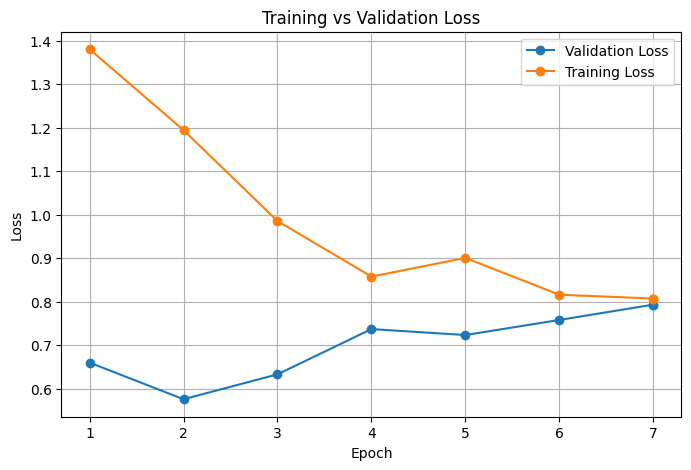

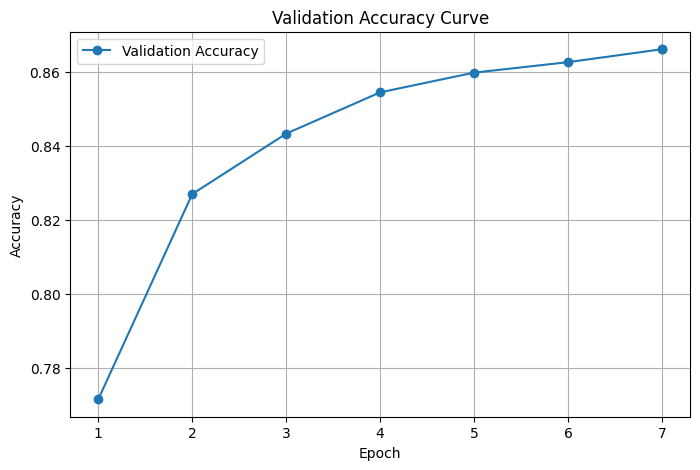

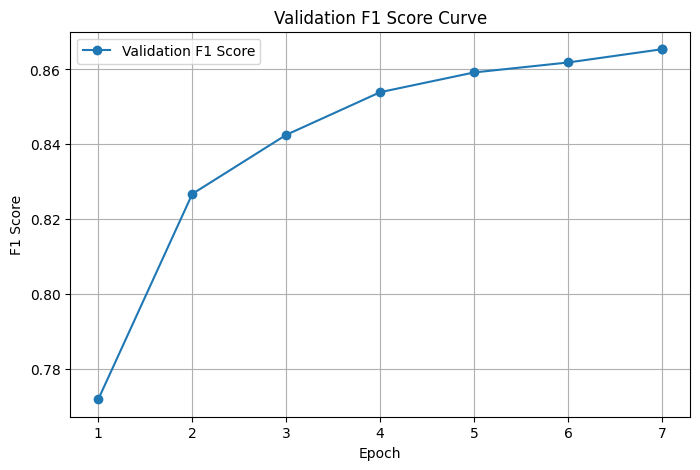

In [ ]:
# ── Accuracy & Loss Curves ───────────────────────────

import matplotlib.pyplot as plt

# Get training history
history = trainer.state.log_history

# -----------------------------------------------------
# EXTRACT VALUES
# -----------------------------------------------------

train_loss = []
eval_loss  = []
eval_acc   = []
eval_f1    = []
epochs     = []

for log in history:

    # Training loss
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])

    # Validation metrics
    if 'eval_loss' in log:

        eval_loss.append(log['eval_loss'])

        eval_acc.append(log['eval_accuracy'])

        eval_f1.append(log['eval_f1'])

        epochs.append(log['epoch'])

# -----------------------------------------------------
# LOSS CURVE
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    eval_loss,
    marker='o',
    label='Validation Loss'
)

# Adjust training loss length
if len(train_loss) >= len(epochs):

    plt.plot(
        epochs,
        train_loss[:len(epochs)],
        marker='o',
        label='Training Loss'
    )

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# -----------------------------------------------------
# ACCURACY CURVE
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    eval_acc,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Validation Accuracy Curve")

plt.legend()

plt.grid(True)

plt.show()

# -----------------------------------------------------
# F1 SCORE CURVE
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    eval_f1,
    marker='o',
    label='Validation F1 Score'
)

plt.xlabel("Epoch")

plt.ylabel("F1 Score")

plt.title("Validation F1 Score Curve")

plt.legend()

plt.grid(True)

plt.show()

<Figure size 800x600 with 0 Axes>

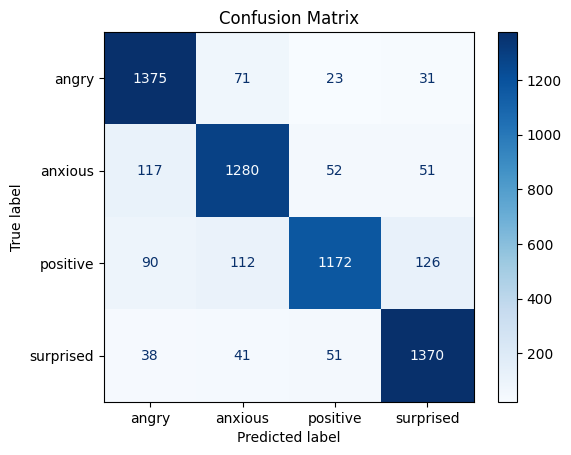

In [ ]:
# ── Display Confusion Matrix ─────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# -----------------------------------------------------
# CREATE FIGURE
# -----------------------------------------------------

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        id2emotion[i]
        for i in range(4)
    ]
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix")

plt.grid(False)

plt.show()

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/final_roberta_model"

os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Drive folder ready")

✅ Drive folder ready


In [ ]:
model.save_pretrained(SAVE_DIR)

tokenizer.save_pretrained(SAVE_DIR)

print("✅ Model saved to Google Drive")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to Google Drive


In [ ]:
import json

emotion2id = {
    'angry': 0,
    'anxious': 1,
    'positive': 2,
    'surprised': 3
}

with open(
    f"{SAVE_DIR}/emotion_map.json",
    "w"
) as f:

    json.dump(emotion2id, f)

print("✅ Emotion mapping saved")

✅ Emotion mapping saved


In [ ]:
# ── Save DistilBERT Model to Google Drive ───────
import os
import json

# Folder path in Google Drive
SAVE_DIR = "/content/drive/MyDrive/distilbert_text_model"

# Create folder
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model
model.save_pretrained(SAVE_DIR)

# Save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# Save label mapping
with open(f"{SAVE_DIR}/label_map.json",
          "w") as f:

    json.dump(id2emotion, f)

print("✅Model Saved to Google Drive")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

path = '/content/drive/MyDrive/final_roberta_model'
print("RoBERTa model files:")
for f in os.listdir(path):
    size = os.path.getsize(f'{path}/{f}')
    print(f"  {f} — {size/(1024*1024):.1f} MB")

Mounted at /content/drive
RoBERTa model files:
  config.json — 0.0 MB
  model.safetensors — 475.5 MB
  tokenizer_config.json — 0.0 MB
  tokenizer.json — 3.4 MB
  emotion_map.json — 0.0 MB
